- This notebook calculates matter effect on $P\mu\mu$ using the full 3-flavor oscillation
- Take earth's density profile into account

In [1]:
import numpy as np
from scipy.linalg import expm

r_e = 6371 # km
d = 20
s = 1.5

def prop_length(x):
    # x is cos(theta)
    sqrt = np.sqrt(4*x**2*(s-r_e)**2-4*(s**2-2*r_e*s-d**2-2*r_e*d))
    return 1/2 * (-2*x*(r_e-s)+sqrt)

def baseline(x):
    if x < 0:
        L = -2*r_e*x
    else:
        L = prop_length(x)
    return L

def pmumu_matter_full(
    L_km,
    E_GeV,
    rho=2.8,
    Ye=0.5,
    theta12=np.deg2rad(33.44),
    theta13=np.deg2rad(8.57),
    theta23=np.deg2rad(49.2),
    delta_cp=np.deg2rad(195.0),
    dm21=7.42e-5,
    dm31=2.517e-3,
    antineutrino=False,
    baseline_type = 'km'
):
    """
    Full 3-flavor nu_mu survival probability in constant-density matter.

    Parameters
    ----------
    L_km : float
        Baseline in km.
    E_GeV : float
        Neutrino energy in GeV.
    rho : float
        Matter density in g/cm^3.
    Ye : float
        Electron fraction.
    theta12, theta13, theta23 : float
        Mixing angles in radians.
    delta_cp : float
        CP phase in radians.
    dm21, dm31 : float
        Mass-squared splittings in eV^2.
        Use dm31 > 0 for normal ordering, dm31 < 0 for inverted ordering.
    antineutrino : bool
        If True, use anti-neutrino Hamiltonian:
        U -> U* and matter potential a -> -a.

    Returns
    -------
    float
        P(nu_mu -> nu_mu)
    """

    if baseline_type == 'cos':
        # Convert cos(theta) to baseline in km
        L_km = baseline(L_km)
    elif baseline_type == 'km':
        pass  # L_km is already in km
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")

    # PMNS matrix
    c12, s12 = np.cos(theta12), np.sin(theta12)
    c13, s13 = np.cos(theta13), np.sin(theta13)
    c23, s23 = np.cos(theta23), np.sin(theta23)

    U = np.array([
        [c12 * c13,
         s12 * c13,
         s13 * np.exp(-1j * delta_cp)],

        [-s12 * c23 - c12 * s23 * s13 * np.exp(1j * delta_cp),
         c12 * c23 - s12 * s23 * s13 * np.exp(1j * delta_cp),
         s23 * c13],

        [s12 * s23 - c12 * c23 * s13 * np.exp(1j * delta_cp),
         -c12 * s23 - s12 * c23 * s13 * np.exp(1j * delta_cp),
         c23 * c13]
    ], dtype=complex)

    if antineutrino:
        U = np.conjugate(U)

    # Vacuum mass-squared matrix (m1^2 set to 0)
    M2_vac = np.diag([0.0, dm21, dm31])

    # Matter potential in eV^2
    # a = 2*sqrt(2)*GF*Ne*E ≈ 2 * 7.63247e-5 * rho[g/cm^3] * Ye * E[GeV]
    a = 2 * 7.63247e-5 * rho * Ye * E_GeV
    if antineutrino:
        a = -a

    V = np.diag([a, 0.0, 0.0])

    # Effective mass-squared matrix in flavor basis
    M2_flavor = U @ M2_vac @ U.conj().T + V

    # Hamiltonian in 1/km units:
    # H = (1 / (2E)) M2, with the usual conversion factor 1.267
    H = 2 * 1.267 * M2_flavor / E_GeV

    # Evolution operator: exp[-i H L]
    S = expm(-1j * H * L_km)

    # nu_mu is index 1
    amp = S[1, 1]
    prob = np.abs(amp) ** 2

    # Remove tiny numerical drift outside [0,1]
    return float(np.clip(prob.real, 0.0, 1.0))

In [35]:
baseline(np.cos(np.deg2rad(154)))

np.float64(11452.433737943986)

In [36]:
np.sqrt(6371**2-5700**2)*2

np.float64(5691.97364716317)

In [2]:
import numpy as np
from scipy.linalg import expm

r_e = 6371.0  # km

def rho_along_path(s_km, L_total_km):
    """
    Density at position s along a chord of total length L_total_km.
    s=0 is entry point, s=L_total_km is exit point.
    """
    b = np.sqrt(max(r_e**2 - (L_total_km / 2.0)**2, 0.0))  # impact parameter
    x = s_km - L_total_km / 2.0
    r = np.sqrt(b**2 + x**2)

    if r < 3480:
        return 11.0
    elif r < 5700:
        return 5.11
    elif r < 6371:
        return 3.15
    else:
        return 0.0
    
def pmumu_matter_profile(
    L_km,
    E_GeV,
    Ye=0.5,
    n_steps=2000,
    theta12=np.deg2rad(33.44),
    theta13=np.deg2rad(8.57),
    theta23=np.deg2rad(49.2),
    delta_cp=np.deg2rad(195.0),
    dm21=7.42e-5,
    dm31=2.517e-3,
    antineutrino=False,
    baseline_type = 'km'
):
    
    if baseline_type == 'cos':
        # Convert cos(theta) to baseline in km
        L_km = baseline(L_km)
    elif baseline_type == 'km':
        pass  # L_km is already in km
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    c12, s12 = np.cos(theta12), np.sin(theta12)
    c13, s13 = np.cos(theta13), np.sin(theta13)
    c23, s23 = np.cos(theta23), np.sin(theta23)

    U = np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*delta_cp)],
        [-s12*c23 - c12*s23*s13*np.exp(1j*delta_cp),
         c12*c23 - s12*s23*s13*np.exp(1j*delta_cp),
         s23*c13],
        [s12*s23 - c12*c23*s13*np.exp(1j*delta_cp),
         -c12*s23 - s12*c23*s13*np.exp(1j*delta_cp),
         c23*c13]
    ], dtype=complex)

    if antineutrino:
        U = np.conjugate(U)

    M2_vac = np.diag([0.0, dm21, dm31])
    M2_vac_flavor = U @ M2_vac @ U.conj().T

    coeff = 2.0 * 1.267
    dL = L_km / n_steps

    S_total = np.eye(3, dtype=complex)

    for i in range(n_steps):
        # midpoint of this slice
        s_mid = (i + 0.5) * dL
        rho = rho_along_path(s_mid, L_km)

        a = 2 * 7.63247e-5 * rho * Ye * E_GeV
        if antineutrino:
            a = -a

        V = np.diag([a, 0.0, 0.0])
        M2_flavor = M2_vac_flavor + V

        S_step = expm(-1j * coeff * M2_flavor * dL / E_GeV)

        # later slices multiply on the left
        S_total = S_step @ S_total

    amp = S_total[1, 1]
    return float(np.clip(np.abs(amp)**2, 0.0, 1.0))

In [3]:
def pmumu_matter_profile_sliced(
    L_km,
    E_GeV,
    Ye=0.5,
    n_steps=2000,
    theta12=np.deg2rad(33.44),
    theta13=np.deg2rad(8.57),
    theta23=np.deg2rad(49.2),
    delta_cp=np.deg2rad(195.0),
    dm21=7.42e-5,
    dm31=2.517e-3,
    antineutrino=False,
    baseline_type='km'
):
    """Return array of probabilities at each slice position."""
    
    if baseline_type == 'cos':
        L_km = baseline(L_km)
    
    c12, s12 = np.cos(theta12), np.sin(theta12)
    c13, s13 = np.cos(theta13), np.sin(theta13)
    c23, s23 = np.cos(theta23), np.sin(theta23)

    U = np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*delta_cp)],
        [-s12*c23 - c12*s23*s13*np.exp(1j*delta_cp),
         c12*c23 - s12*s23*s13*np.exp(1j*delta_cp),
         s23*c13],
        [s12*s23 - c12*c23*s13*np.exp(1j*delta_cp),
         -c12*s23 - s12*c23*s13*np.exp(1j*delta_cp),
         c23*c13]
    ], dtype=complex)

    if antineutrino:
        U = np.conjugate(U)

    M2_vac = np.diag([0.0, dm21, dm31])
    M2_vac_flavor = U @ M2_vac @ U.conj().T

    coeff = 2.0 * 1.267
    dL = L_km / n_steps

    S_total = np.eye(3, dtype=complex)
    probs = []

    for i in range(n_steps):
        s_mid = (i + 0.5) * dL
        rho = rho_along_path(s_mid, L_km)

        a = 2 * 7.63247e-5 * rho * Ye * E_GeV
        if antineutrino:
            a = -a

        V = np.diag([a, 0.0, 0.0])
        M2_flavor = M2_vac_flavor + V

        S_step = expm(-1j * coeff * M2_flavor * dL / E_GeV)
        S_total = S_step @ S_total
        
        probs.append(np.abs(S_total[1, 1])**2)

    return np.array(probs)

In [39]:
np.sqrt(2)*(1.166e-5)*(6.022e23)*(1.97327e-14)**3 * 1e18

np.float64(7.629812039797628e-05)

In [12]:
def p_mumu_vac(L, E):
    dm31=2.517e-3
    theta13=np.deg2rad(8.57)
    theta23=np.deg2rad(49.2)
    s13 = np.sin(theta13)**2
    s23 = np.sin(theta23)**2
    phase = 1.27 * dm31 * L / E

    c13_sq = 1.0 - s13
    c13_4 = c13_sq**2

    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)
    sin2_2theta13 = 4.0 * s13 * (1.0 - s13)

    return 1.0 - c13_4 * sin2_2theta23 * np.sin(phase)**2 - s23 * sin2_2theta13 * np.sin(phase)**2


def p_mumu_vac_sliced(
    L_km,
    E_GeV,
    n_steps=2000,
    baseline_type='km'
):
    """Return vacuum survival probabilities at each step along the path."""
    if baseline_type == 'cos':
        L_km = baseline(L_km)

    L_steps = np.linspace(0, L_km, n_steps)
    return np.array([p_mumu_vac(L, E_GeV) for L in L_steps])


def p_matter_sliced(
    L_km,
    E_GeV,
    rho=2.8,
    Ye=0.5,
    n_steps=2000,
    baseline_type='km'
):
    """Return constant-density matter survival probabilities at each step along the path."""
    if baseline_type == 'cos':
        L_km = baseline(L_km)

    L_steps = np.linspace(0, L_km, n_steps)
    return np.array([
        pmumu_matter_full(
            L_km=L,
            E_GeV=E_GeV,
            rho=rho,
            Ye=Ye,
            baseline_type='km'
        )
        for L in L_steps
    ])


In [5]:
def p_mumu_vac_full(
    L_km,
    E_GeV,
    theta12=np.deg2rad(33.44),
    theta13=np.deg2rad(8.57),
    theta23=np.deg2rad(49.2),
    delta_cp=np.deg2rad(195.0),
    dm21=7.42e-5,
    dm31=2.517e-3,
    baseline_type = 'km'
):
    
    if baseline_type == 'cos':
        # Convert cos(theta) to baseline in km
        L_km = baseline(L_km)
    elif baseline_type == 'km':
        pass  # L_km is already in km
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")

    c12, s12 = np.cos(theta12), np.sin(theta12)
    c13, s13 = np.cos(theta13), np.sin(theta13)
    c23, s23 = np.cos(theta23), np.sin(theta23)

    U_mu1 = -s12*c23 - c12*s23*s13*np.exp(1j*delta_cp)
    U_mu2 =  c12*c23 - s12*s23*s13*np.exp(1j*delta_cp)
    U_mu3 =  s23*c13

    u1 = np.abs(U_mu1)**2
    u2 = np.abs(U_mu2)**2
    u3 = np.abs(U_mu3)**2

    dm32 = dm31 - dm21

    phase21 = 1.267 * dm21 * L_km / E_GeV
    phase31 = 1.267 * dm31 * L_km / E_GeV
    phase32 = 1.267 * dm32 * L_km / E_GeV

    P = (
        1.0
        - 4.0*u1*u2*np.sin(phase21)**2
        - 4.0*u1*u3*np.sin(phase31)**2
        - 4.0*u2*u3*np.sin(phase32)**2
    )

    return float(np.clip(P.real, 0.0, 1.0))

In [42]:
s23 = np.sin(np.deg2rad(49.2))**2
print(s23)

0.5730415142812058


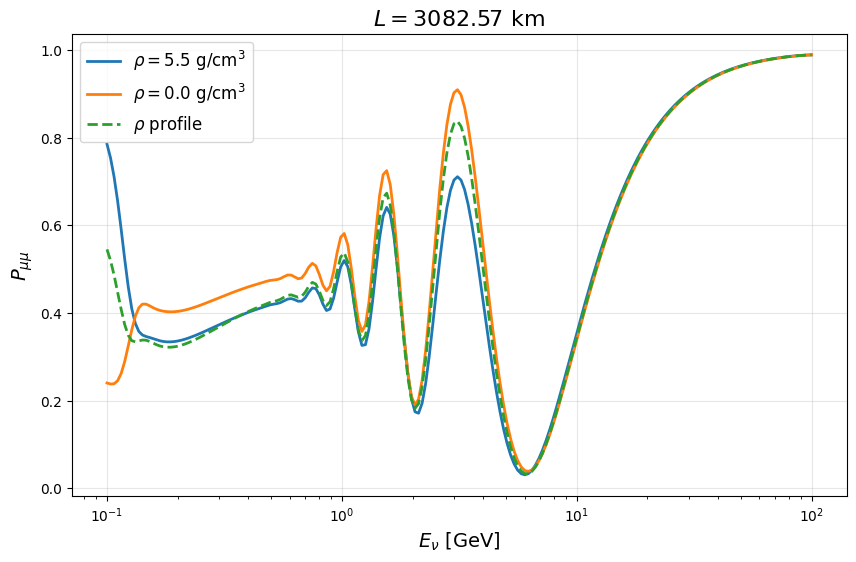

<Figure size 640x480 with 0 Axes>

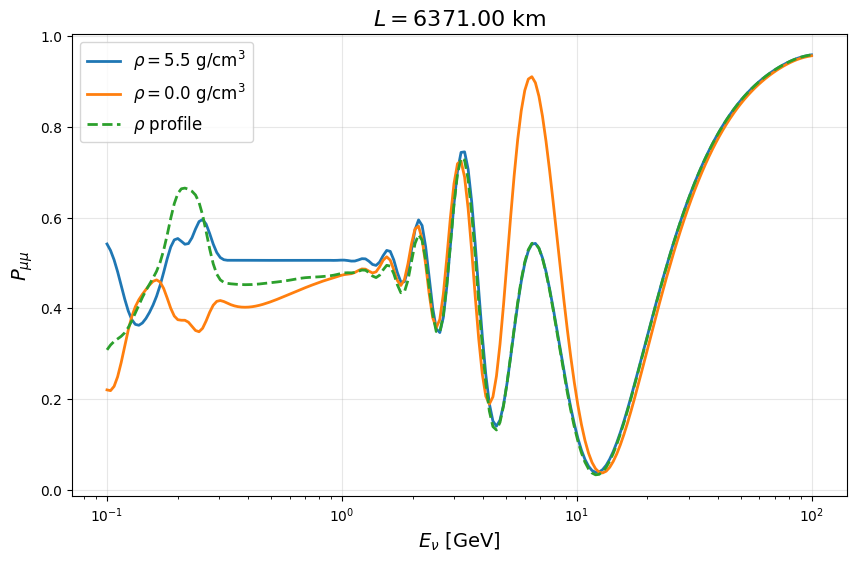

<Figure size 640x480 with 0 Axes>

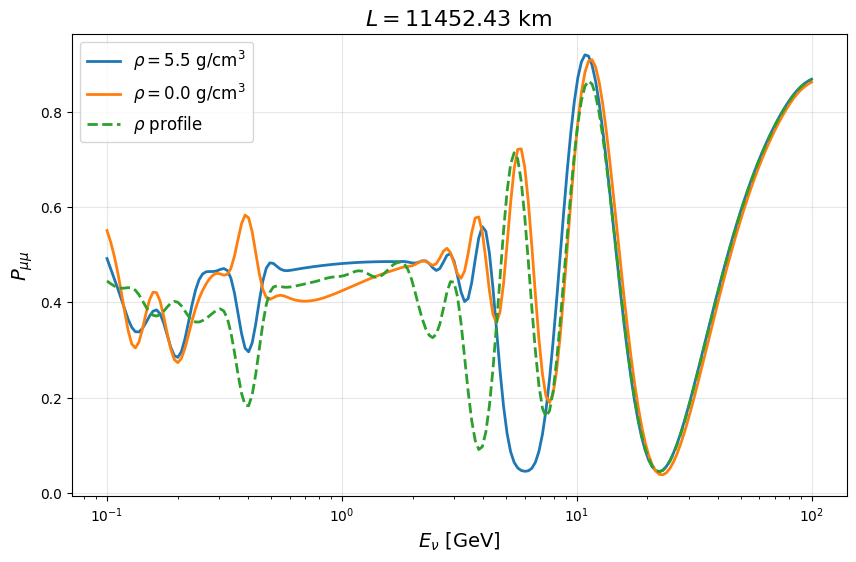

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

def smear_probabilities(E, P, resolution=0.1):
    lnE = np.log(E)
    P_smeared = np.zeros_like(P)
    for i, lnE0 in enumerate(lnE):
        weights = np.exp(-0.5 * ((lnE - lnE0) / resolution)**2)
        P_smeared[i] = np.sum(weights * P) / np.sum(weights)
    return P_smeared

rho_avg = 5.5
rho_list = [rho_avg, 0]  # g/cm^3
L_list = [baseline(np.cos(np.deg2rad(104))), baseline(np.cos(np.deg2rad(120))), baseline(np.cos(np.deg2rad(154)))]
energy_list = np.geomspace(0.1, 100, 200)
p_mumu_list = np.array([p_mumu_vac_full(L_km=9700, E_GeV=i) for i in energy_list])
for L in L_list:
    plt.figure(figsize=(10, 6))
    #plt.plot(energy_list, p_mumu_list, label='vac', linewidth=2)

    for rho in rho_list:
        p_matter = np.array([pmumu_matter_full(L_km=L, E_GeV=i, rho=rho) for i in energy_list])
        p_matter_smear = smear_probabilities(energy_list, p_matter, resolution=0.1)
        plt.plot(energy_list, p_matter_smear, label=r'$\rho = %.1f$ g/cm$^3$' % rho, linewidth=2)

    p_profile = np.array([pmumu_matter_profile(L_km=L, E_GeV=i) for i in energy_list])
    p_profile_smear = smear_probabilities(energy_list, p_profile, resolution=0.1)
    plt.plot(energy_list, p_profile_smear, label=r'$\rho$ profile', linestyle='dashed', linewidth=2)
    plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
    plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
    plt.xscale('log')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.title(rf'$L = {L:.2f}$ km', fontsize=16)
    plt.show()
    plt.savefig(f"p_mumu_matter_{L}km.pdf", dpi=300)


In [9]:
# Do the same thing but for baseline in km instead of cos(theta)
zenith_angles = np.linspace(-0.95, 0.95, 200)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = pmumu_matter_full(L_km=L, E_GeV=E, rho=2.8, baseline_type='cos')-p_mumu_vac_full(L_km=L, E_GeV=E, baseline_type='cos') 
plt.figure(figsize=(12, 8))
prob_min = np.min(prob_grid)
prob_max = np.max(prob_grid)
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest', vmin = -0.3, vmax = 0.1)
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'$P_{\mu\mu}^m - P_{\mu\mu}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu\mu}^m - P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('p_mumu_matter_oscillogram_diff_full.pdf', dpi=300)
plt.show()

KeyboardInterrupt: 

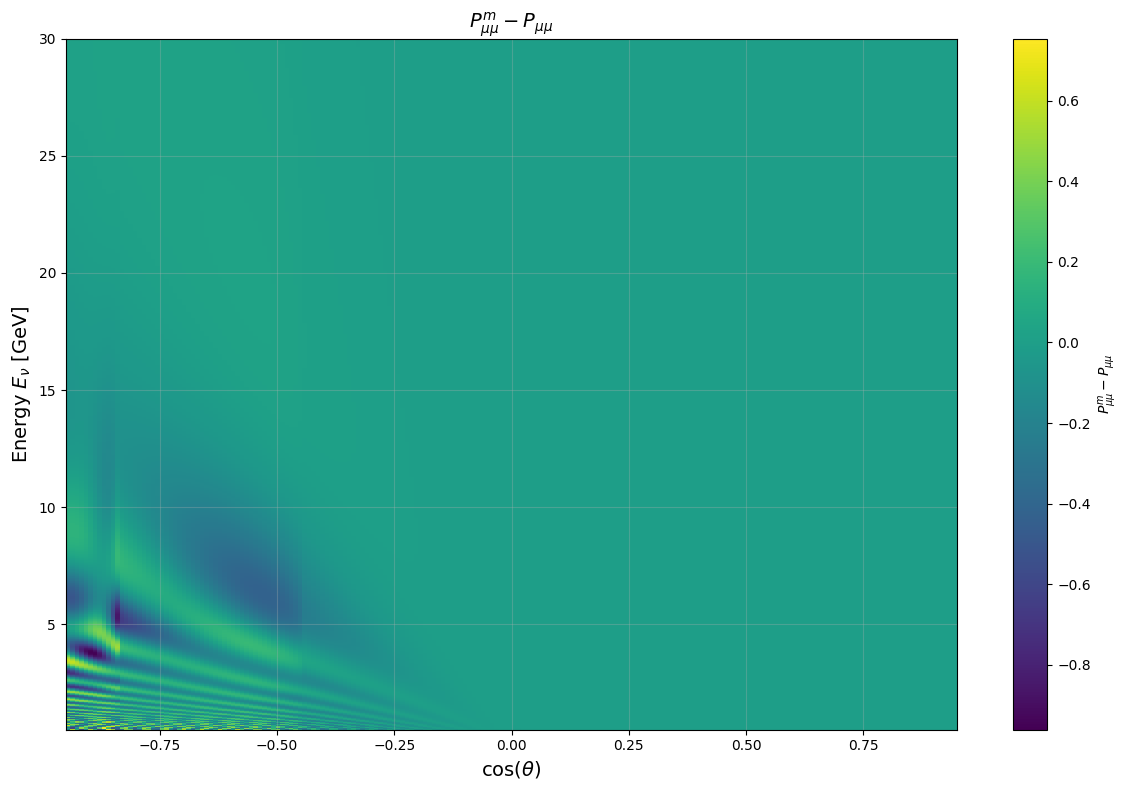

In [ ]:
# Do the same thing but for baseline in km instead of cos(theta)
zenith_angles = np.linspace(-0.95, 0.95, 200)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = pmumu_matter_profile(L_km=L, E_GeV=E, baseline_type='cos')-p_mumu_vac_full(L_km=L, E_GeV=E, baseline_type='cos') 
plt.figure(figsize=(12, 8))
prob_min = np.min(prob_grid)
prob_max = np.max(prob_grid)
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest', vmin = prob_min, vmax = prob_max)
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'$P_{\mu\mu}^m - P_{\mu\mu}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu\mu}^m - P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_matter_oscillogram_diff_profile.pdf', dpi=300)
plt.show()

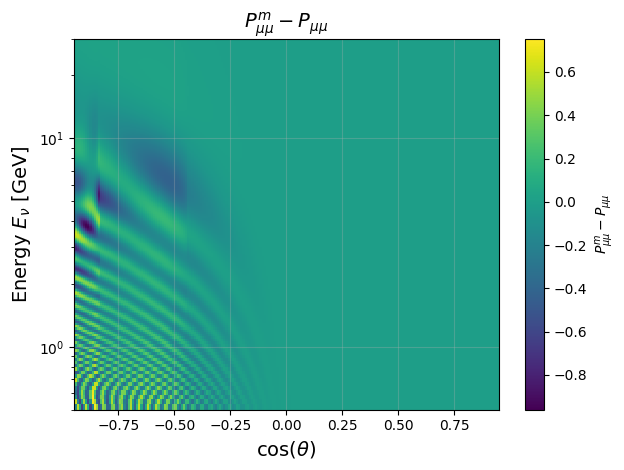

In [ ]:
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest', vmin = prob_min, vmax = prob_max)
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
# log
plt.xscale('linear')
plt.yscale('log')
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'$P_{\mu\mu}^m - P_{\mu\mu}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu\mu}^m - P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

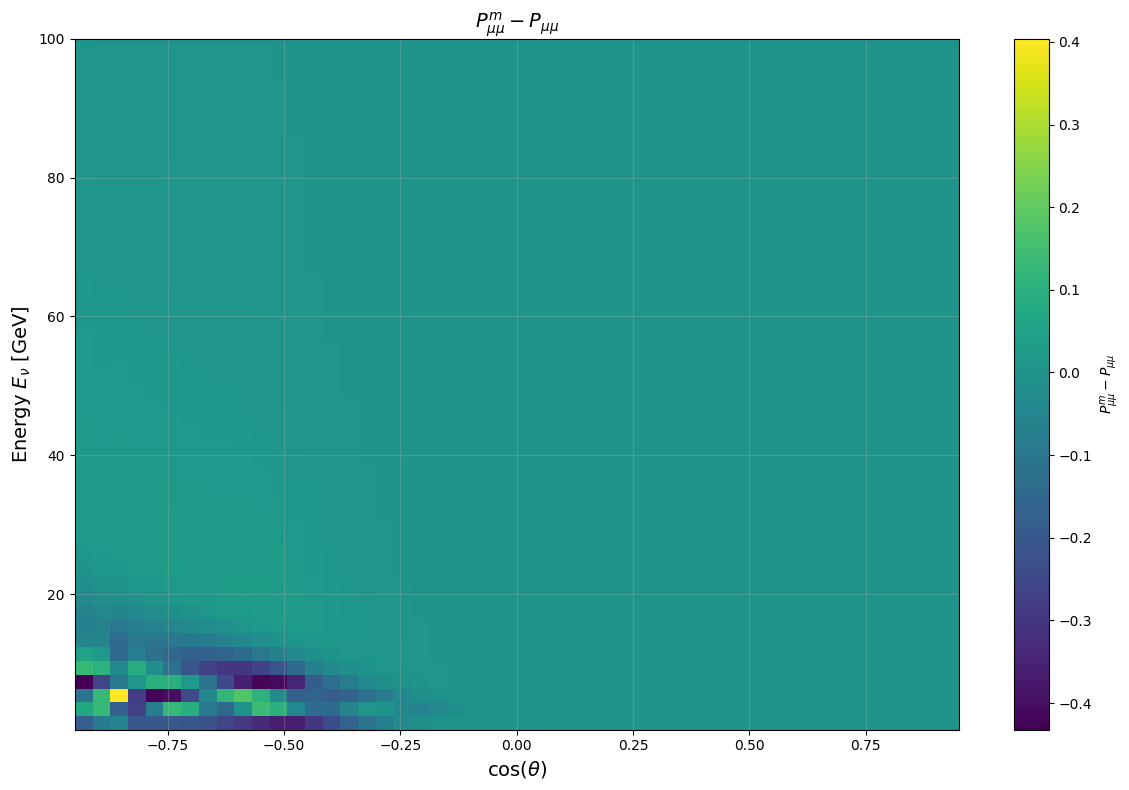

In [ ]:
# Do the same thing but for baseline in km instead of cos(theta)
zenith_angles = np.linspace(-0.95, 0.95, 50)
baseline_km = np.linspace(0, 12742, 200)  # Earth diameter in km
energies_for_heatmap = np.linspace(0.5, 100, 50)
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, L in enumerate(zenith_angles):
        prob_grid[i, j] = pmumu_matter_profile(L_km=L, E_GeV=E, baseline_type='cos')-p_mumu_vac_full(L_km=L, E_GeV=E, baseline_type='cos') 
plt.figure(figsize=(12, 8))
prob_min = np.min(prob_grid)
prob_max = np.max(prob_grid)
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[zenith_angles[0], zenith_angles[-1],
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest', vmin = prob_min, vmax = prob_max)
plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'$P_{\mu\mu}^m - P_{\mu\mu}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu\mu}^m - P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def smear_probabilities(E, P, resolution=0.1):
    lnE = np.log(E)
    P_smeared = np.zeros_like(P)
    for i, lnE0 in enumerate(lnE):
        weights = np.exp(-0.5 * ((lnE - lnE0) / resolution)**2)
        P_smeared[i] = np.sum(weights * P) / np.sum(weights)
    return P_smeared

rho_avg = 5.5
rho_list = [rho_avg, 0]  # g/cm^3
L_list = [baseline(np.cos(np.deg2rad(104))), baseline(np.cos(np.deg2rad(120))), baseline(np.cos(np.deg2rad(154)))]
energy_list = np.geomspace(0.1, 100, 200)
p_mumu_list = np.array([p_mumu_vac_full(L_km=9700, E_GeV=i) for i in energy_list])
for L in L_list:
    plt.figure(figsize=(10, 6))
    #plt.plot(energy_list, p_mumu_list, label='vac', linewidth=2)

    for rho in rho_list:
        p_matter = np.array([pmumu_matter_full(L_km=L, E_GeV=i, rho=rho) for i in energy_list])
        p_matter_smear = smear_probabilities(energy_list, p_matter, resolution=0.1)
        plt.plot(energy_list, p_matter_smear, label=r'$\rho = %.1f$ g/cm$^3$' % rho, linewidth=2)

    p_profile = np.array([pmumu_matter_profile(L_km=L, E_GeV=i) for i in energy_list])
    p_profile_smear = smear_probabilities(energy_list, p_profile, resolution=0.1)
    plt.plot(energy_list, p_profile_smear, label=r'$\rho$ profile', linestyle='dashed', linewidth=2)
    plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
    plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
    plt.xscale('log')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.title(rf'$L = {L:.2f}$ km', fontsize=16)
    plt.show()
    plt.savefig(f"p_mumu_matter_{L}km.pdf", dpi=300)

Baseline: 11490.83 km, Energy: 3.81 GeV


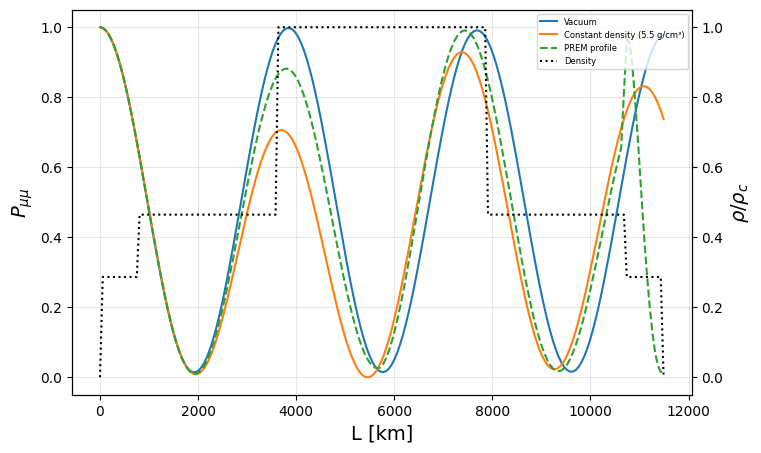

Baseline: 10753.94 km, Energy: 5.36 GeV


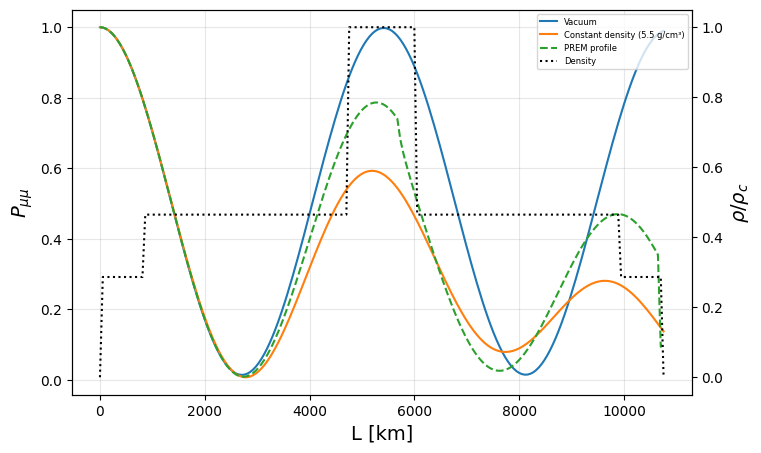

Baseline: 10753.94 km, Energy: 8.00 GeV


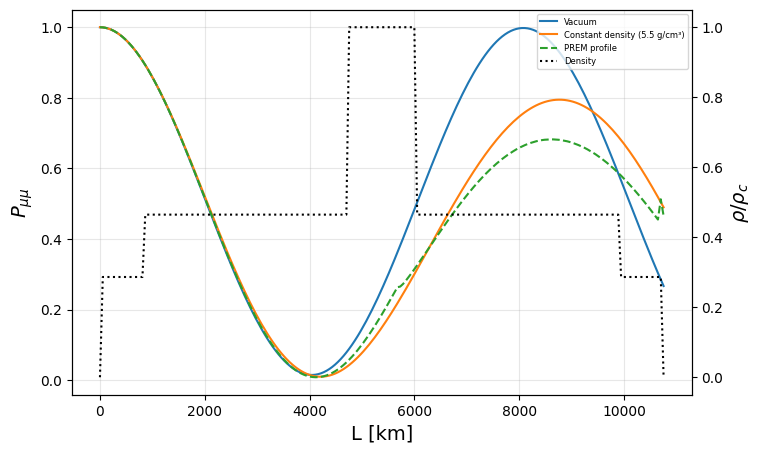

In [ ]:
import matplotlib.pyplot as plt

# Assuming the rest of the code is as before

point_A = [-0.9018072289156627, 3.8060781476121566]
point_B = [-0.8439759036144578, 5.3617945007235885]
point_C = [-0.8439759036144578, 8]
L_list = [baseline(point_A[0]), baseline(point_B[0]), baseline(point_C[0])]
E_list = [point_A[1], point_B[1], point_C[1]]

for L, E in zip(L_list, E_list):
    baseline_list = np.linspace(0, L, 200)
    print(f"Baseline: {L:.2f} km, Energy: {E:.2f} GeV")
    p_vac = np.array([p_mumu_vac_full(L_km=b, E_GeV=E, baseline_type='km') for b in baseline_list])
    p_matter = np.array([pmumu_matter_full(L_km=b, E_GeV=E, rho=5.5, baseline_type='km') for b in baseline_list])
    p_profile = np.array([pmumu_matter_profile(L_km=b, E_GeV=E, baseline_type='km') for b in baseline_list])
    
    # Compute density along the path
    rho_list = np.array([rho_along_path(s, L)/11 for s in baseline_list])
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Plot probabilities on the left y-axis
    ax1.plot(baseline_list, p_vac, label='Vacuum')
    ax1.plot(baseline_list, p_matter, label='Constant density (5.5 g/cm³)')
    ax1.plot(baseline_list, p_profile, label='PREM profile', linestyle='dashed')
    ax1.set_xlabel(r"L [km]", fontsize=14)
    ax1.set_ylabel(r"$P_{\mu\mu}$", fontsize=14)
    ax1.legend(loc='upper left', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Create second y-axis for density
    ax2 = ax1.twinx()
    ax2.plot(baseline_list, rho_list, label='Density', color='black', linestyle='dotted')
    ax2.set_ylabel(r"$\rho/\rho_c$", fontsize=14, color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    
    # Combine legends if needed
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=6)
    
    plt.show()
    # plt.savefig(f"p_mumu_matter_{L}km.pdf", dpi=300)

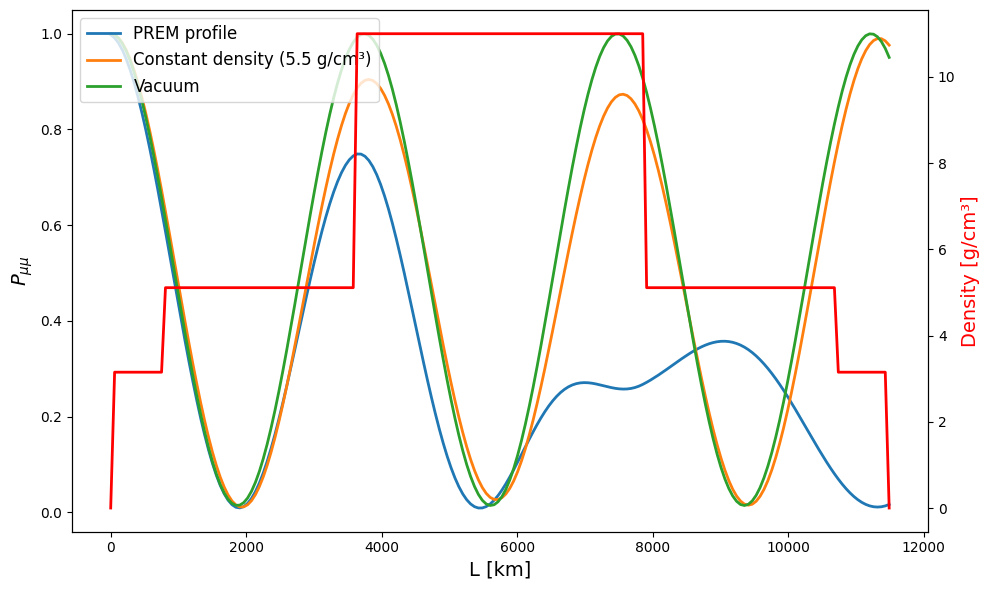

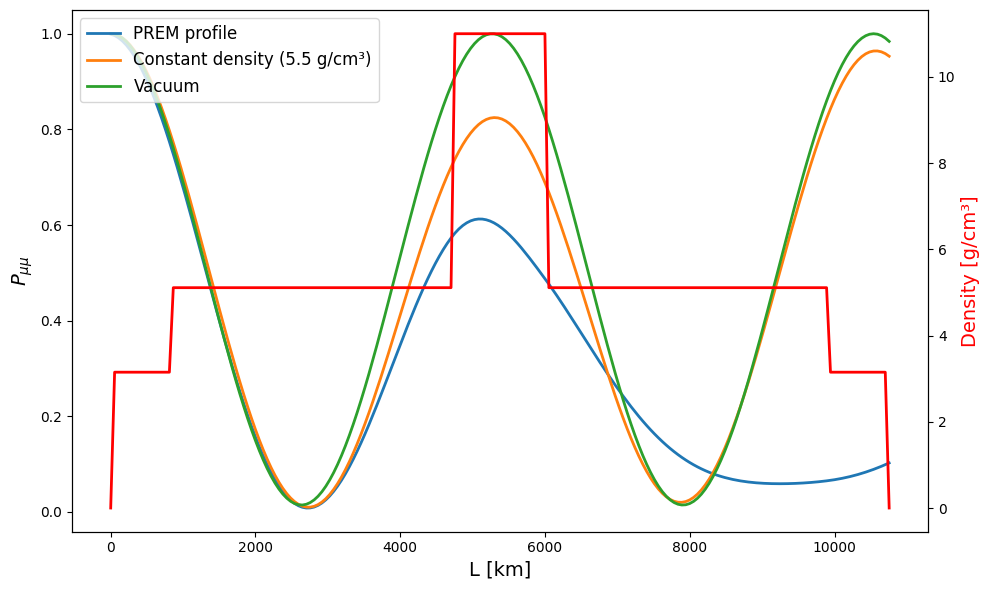

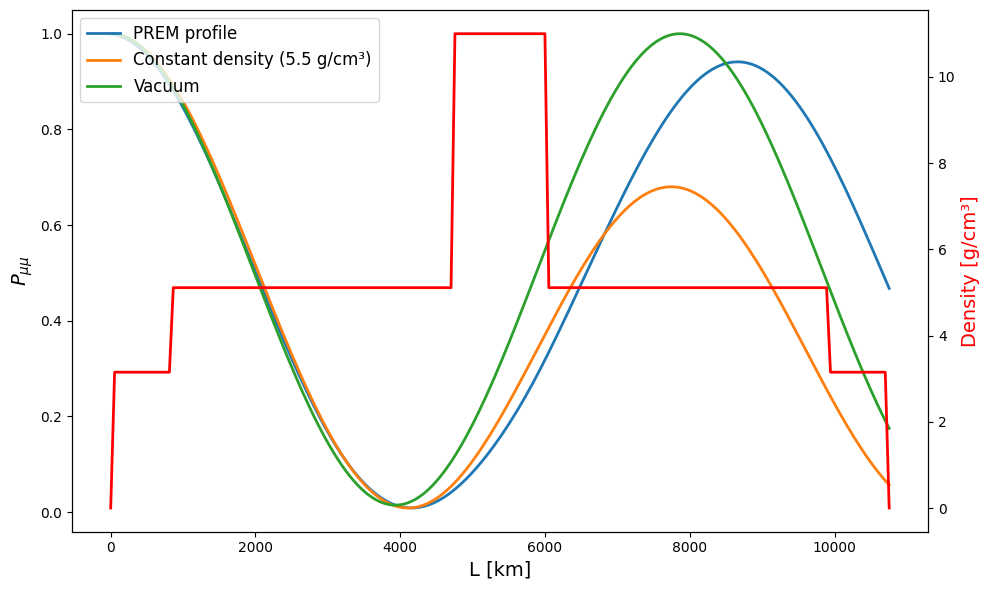

In [ ]:
import matplotlib.pyplot as plt

# Assuming the rest of the code is as before

point_A = [-0.9018072289156627, 3.8060781476121566]
point_B = [-0.8439759036144578, 5.3617945007235885]
point_C = [-0.8439759036144578, 8]
L_list = [baseline(point_A[0]), baseline(point_B[0]), baseline(point_C[0])]
E_list = [point_A[1], point_B[1], point_C[1]]

for L, E in zip(L_list, E_list):
    p_profile = pmumu_matter_profile_sliced(L, E, n_steps=200, baseline_type='km')
    p_matter = p_matter_sliced(L, E, n_steps=200, baseline_type='km', rho = 5.5)
    p_vac = p_mumu_vac_sliced(L, E, n_steps=200, baseline_type='km')
    baseline_list = np.linspace(0, L, len(p_profile))
    rho_list = np.array([rho_along_path(s, L) for s in baseline_list])
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(baseline_list, p_profile, label='PREM profile', linewidth=2)
    ax1.plot(baseline_list, p_matter, label='Constant density (5.5 g/cm³)', linewidth=2)
    ax1.plot(baseline_list, p_vac, label='Vacuum', linewidth=2)
    ax1.legend(loc='upper left', fontsize=12)
    ax1.set_xlabel(r"L [km]", fontsize=14)
    ax1.set_ylabel(r"$P_{\mu\mu}$", fontsize=14)
    
    ax2 = ax1.twinx()
    ax2.plot(baseline_list, rho_list, color='red', linewidth=2, label='Density')
    ax2.set_ylabel(r"Density [g/cm³]", fontsize=14, color='red')
    
    plt.tight_layout()
    plt.show()

In [ ]:
a = baseline(point_B[0])/2
h = np.sqrt(r_e**2 - a**2)
print(h)

3417.2839268164525


In [ ]:
np.sqrt(3480**2-3417**2)

np.float64(659.1744837294599)

In [ ]:
2*659

1318

In [ ]:
10753/2+659

6035.5